In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from medmnist import BreastMNIST, INFO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from scipy import stats
from scipy.datasets import electrocardiogram
from scipy.signal import butter, filtfilt

from scipy.ndimage import (
    median_filter,
    gaussian_filter,
    sobel,
    rotate,
    shift,
    zoom
)

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif
)

from datasets import load_dataset

from collections import Counter

from PIL import Image

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Tabular Data

In [2]:
breast_cancer = load_breast_cancer(as_frame=True)

tabular_df = breast_cancer.frame.copy()

# Rename target to something easier to understand
tabular_df = tabular_df.rename(columns={"target": "diagnosis"})

# sklearn encoding:
# 0 = malignant
# 1 = benign
tabular_df["diagnosis_label"] = tabular_df["diagnosis"].map({
    0: "malignant",
    1: "benign"
})

print("Dataset shape:", tabular_df.shape)

tabular_df.head()

Dataset shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [3]:
print("FIRST FIVE ROWS")
display(tabular_df.head())

print("\nDATA TYPES")
display(tabular_df.dtypes)

print("\nDATASET INFORMATION")
tabular_df.info()

print("\nSUMMARY STATISTICS")
display(tabular_df.describe().T)

FIRST FIVE ROWS


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant



DATA TYPES


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      


DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [4]:
missing_values = pd.DataFrame({
    "Missing Values": tabular_df.isnull().sum(),
    "Percentage": (tabular_df.isnull().sum() / len(tabular_df)) * 100
})

display(
    missing_values[
        missing_values["Missing Values"] > 0
    ].sort_values("Missing Values", ascending=False)
)

print("Total missing values:", tabular_df.isnull().sum().sum())

,Missing Values,Percentage


Total missing values: 0


In [5]:
duplicate_count = tabular_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [6]:
class_counts = tabular_df["diagnosis_label"].value_counts()

print(class_counts)
print("\nClass percentages:")
print(tabular_df["diagnosis_label"].value_counts(normalize=True) * 100)

diagnosis_label
benign       357
malignant    212
Name: count, dtype: int64

Class percentages:
diagnosis_label
benign       62.741652
malignant    37.258348
Name: proportion, dtype: float64


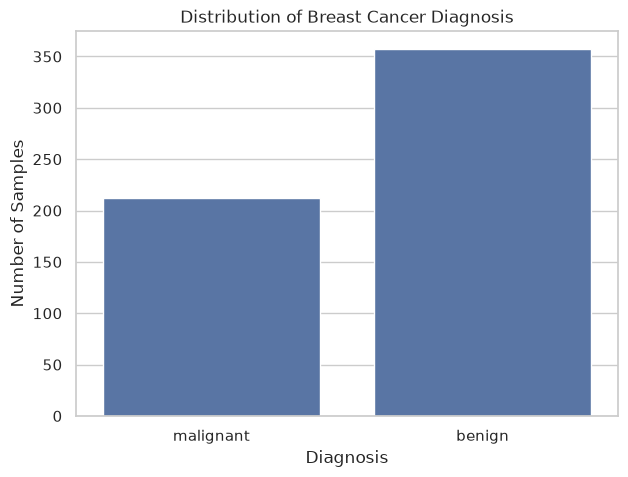

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=tabular_df,
    x="diagnosis_label"
)

plt.title("Distribution of Breast Cancer Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

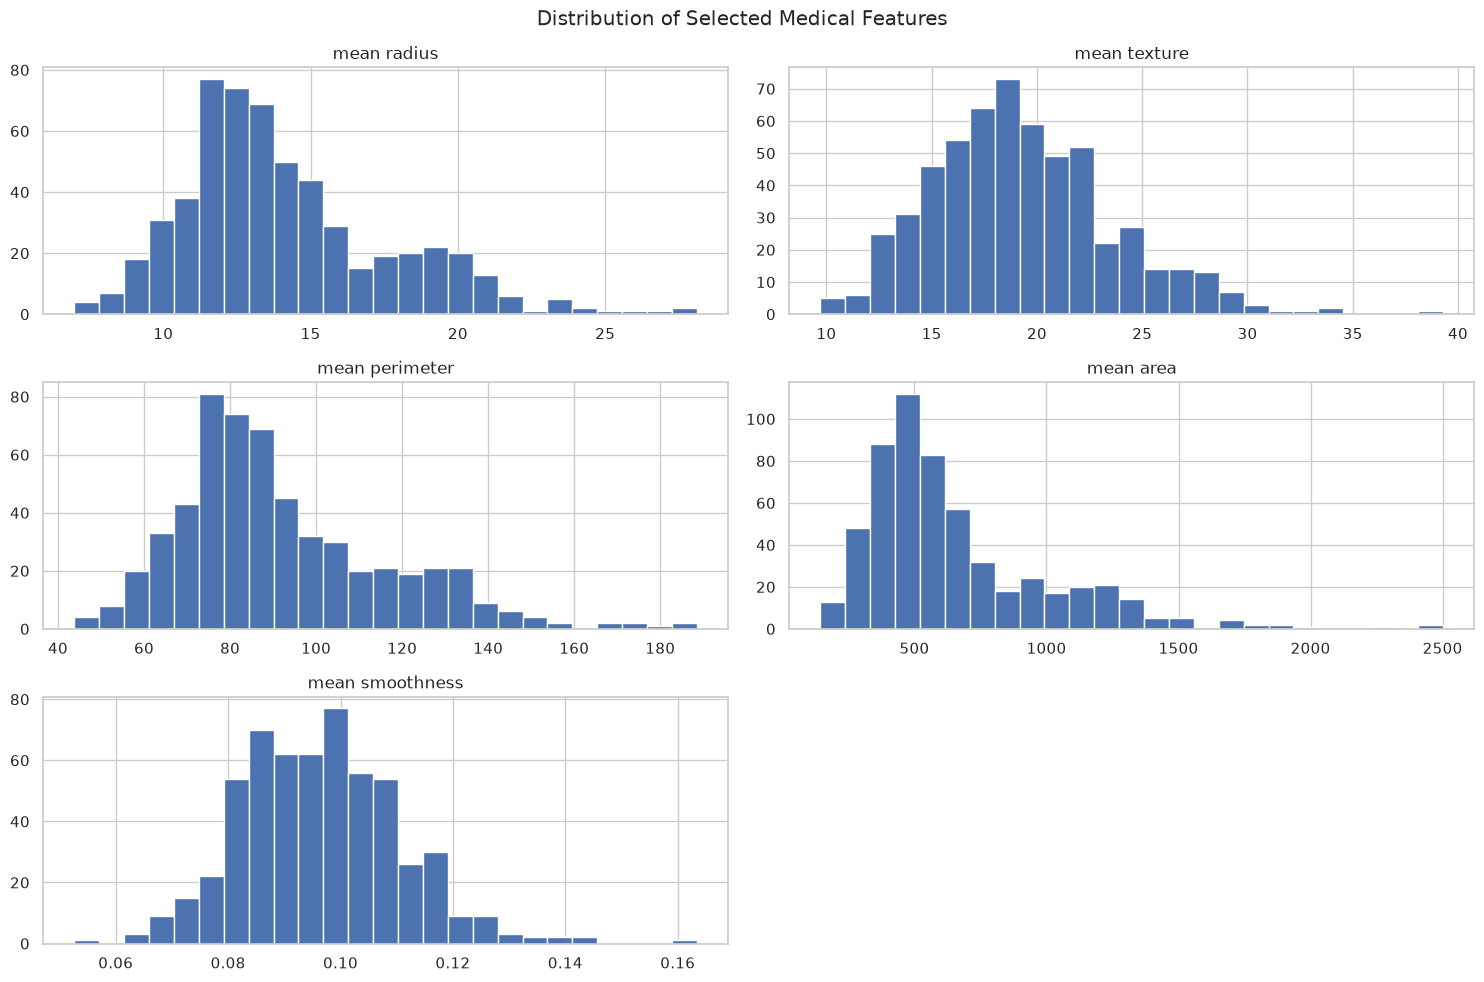

In [8]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

tabular_df[selected_features].hist(
    figsize=(15, 10),
    bins=25
)

plt.suptitle("Distribution of Selected Medical Features")
plt.tight_layout()
plt.show()

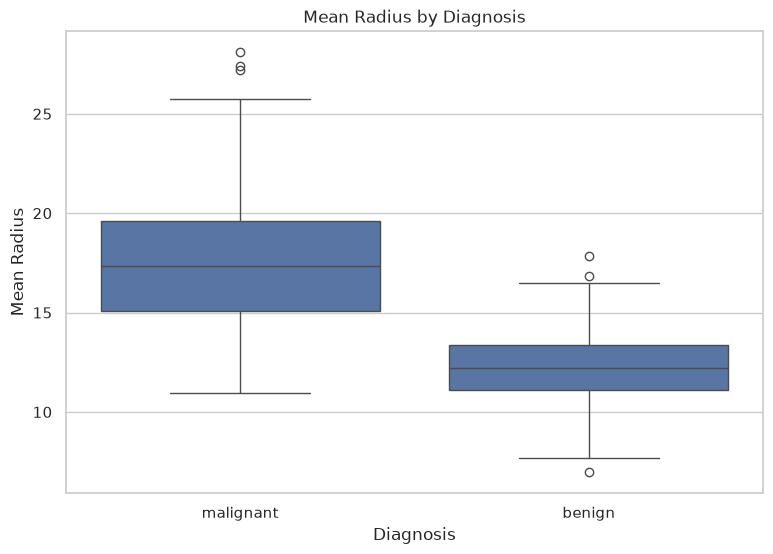

In [9]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=tabular_df,
    x="diagnosis_label",
    y="mean radius"
)

plt.title("Mean Radius by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Radius")

plt.show()

In [10]:
malignant_radius = tabular_df.loc[
    tabular_df["diagnosis_label"] == "malignant",
    "mean radius"
]

benign_radius = tabular_df.loc[
    tabular_df["diagnosis_label"] == "benign",
    "mean radius"
]

t_stat, p_value = stats.ttest_ind(
    malignant_radius,
    benign_radius,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print(
        "\nResult: Reject the null hypothesis."
    )
    print(
        "There is a statistically significant difference "
        "in mean radius between the two diagnosis groups."
    )
else:
    print(
        "\nResult: Fail to reject the null hypothesis."
    )
    print(
        "There is insufficient evidence of a significant "
        "difference in mean radius."
    )

T-statistic: 22.208797758464527
P-value: 1.6844591259582815e-64

Result: Reject the null hypothesis.
There is a statistically significant difference in mean radius between the two diagnosis groups.


Contingency Table:


diagnosis_label,benign,malignant
radius_category,,
Low,185,6
Medium,149,39
High,23,167


Chi-square statistic: 325.4354164758156
P-value: 2.150786017083972e-71
Degrees of freedom: 2

Reject the null hypothesis: radius category and diagnosis are associated.


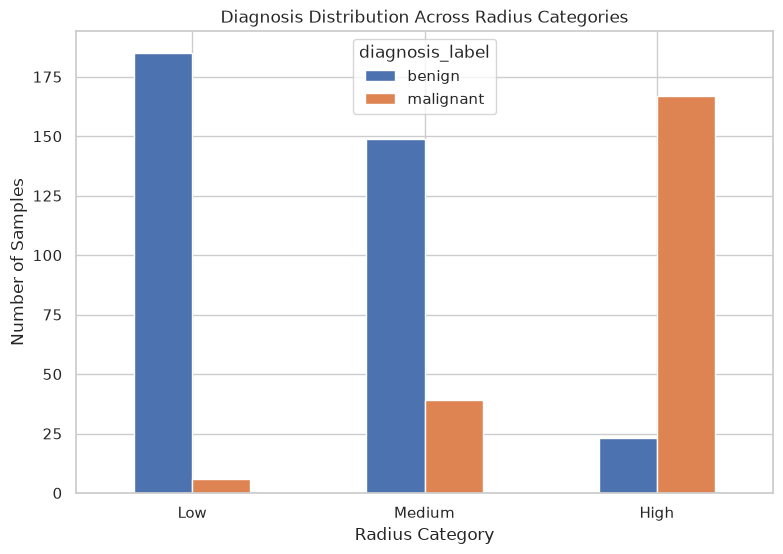

In [11]:
tabular_df["radius_category"] = pd.qcut(
    tabular_df["mean radius"],
    q=3,
    labels=["Low", "Medium", "High"]
)

contingency_table = pd.crosstab(
    tabular_df["radius_category"],
    tabular_df["diagnosis_label"]
)

print("Contingency Table:")
display(contingency_table)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)

if p < 0.05:
    print(
        "\nReject the null hypothesis: "
        "radius category and diagnosis are associated."
    )
else:
    print(
        "\nFail to reject the null hypothesis: "
        "there is insufficient evidence of an association."
    )

contingency_table.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Diagnosis Distribution Across Radius Categories")
plt.xlabel("Radius Category")
plt.ylabel("Number of Samples")

plt.xticks(rotation=0)
plt.show()

In [12]:
low_group = tabular_df.loc[
    tabular_df["radius_category"] == "Low",
    "mean texture"
]

medium_group = tabular_df.loc[
    tabular_df["radius_category"] == "Medium",
    "mean texture"
]

high_group = tabular_df.loc[
    tabular_df["radius_category"] == "High",
    "mean texture"
]

f_stat, p_value = stats.f_oneway(
    low_group,
    medium_group,
    high_group
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print(
        "\nReject H₀: At least one group's mean texture differs significantly."
    )
else:
    print(
        "\nFail to reject H₀: No statistically significant difference detected."
    )

F-statistic: 29.075477527878192
P-value: 9.551730890118103e-13

Reject H₀: At least one group's mean texture differs significantly.


In [13]:
X_tabular = tabular_df.drop(
    columns=[
        "diagnosis",
        "diagnosis_label",
        "radius_category"
    ]
)

y_tabular = tabular_df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X_tabular,
    y_tabular,
    test_size=0.20,
    stratify=y_tabular,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = X_train_scaled.astype(np.float32)
X_test_tensor = X_test_scaled.astype(np.float32)

print("X_train tensor shape:", X_train_tensor.shape)
print("X_test tensor shape:", X_test_tensor.shape)
print("Data type:", X_train_tensor.dtype)

tabular_engineered = X_tabular.copy()

tabular_engineered["radius_texture_interaction"] = (
    tabular_engineered["mean radius"]
    * tabular_engineered["mean texture"]
)

tabular_engineered["compactness_ratio"] = (
    tabular_engineered["mean compactness"]
    /
    (tabular_engineered["mean smoothness"] + 1e-8)
)

tabular_engineered.head()

Training shape: (455, 30)
Testing shape: (114, 30)
X_train tensor shape: (455, 30)
X_test tensor shape: (114, 30)
Data type: float32


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,radius_texture_interaction,compactness_ratio
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,186.7362,2.344594
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,365.5289,0.928015
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,418.4125,1.458941
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,232.7396,1.992281
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,290.9586,1.324028


In [14]:
selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

selected_feature_names = X_train.columns[
    selector.get_support()
]

print("Selected Features:")
print(selected_feature_names.tolist())

print("\nOriginal number of features:", X_train.shape[1])
print("Selected number of features:", X_selected.shape[1])

Selected Features:
['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']

Original number of features: 30
Selected number of features: 10


# Textual Data

In [15]:
medical_text_ds = load_dataset(
    "bhargavi909/Medical_Transcriptions"
)

print(medical_text_ds)

text_df = medical_text_ds["train"].to_pandas()

print("Shape:", text_df.shape)

text_df.head()

DatasetDict({
    train: Dataset({
        features: ['description', 'medical_specialty'],
        num_rows: 3999
    })
    test: Dataset({
        features: ['description', 'medical_specialty'],
        num_rows: 1000
    })
})
Shape: (3999, 2)


,description,medical_specialty
0,"Bilateral Mammogram, (abnormal) additional vi...",33
1,Bronchoscopy with brush biopsies. Persistent...,3
2,This is a middle-aged female with two month h...,22
3,MRI Brain: Thrombus in torcula of venous sinu...,33
4,Followup of moderate-to-severe sleep apnea. ...,15


In [16]:
print(text_df.columns.tolist())

text_df.info()

for column in text_df.columns:
    print(f"\nCOLUMN: {column}")
    print(text_df[column].head(3))

TEXT_COLUMN = "description"

['description', 'medical_specialty']
<class 'pandas.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   description        3999 non-null   str  
 1   medical_specialty  3999 non-null   int64
dtypes: int64(1), str(1)
memory usage: 578.5 KB

COLUMN: description
0     Bilateral Mammogram, (abnormal) additional vi...
1     Bronchoscopy with brush biopsies.  Persistent...
2     This is a middle-aged female with two month h...
Name: description, dtype: str

COLUMN: medical_specialty
0    33
1     3
2    22
Name: medical_specialty, dtype: int64


In [17]:
def clean_medical_text(text):
    """
    Basic demonstration cleaning function.

    This is NOT sufficient for production PHI de-identification.
    """
    
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Remove email-like strings
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        "[REDACTED_EMAIL]",
        text
    )
    
    # Remove phone-like strings
    text = re.sub(
        r"\b(?:\+?1[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b",
        "[REDACTED_PHONE]",
        text
    )
    
    # Remove common date formats
    text = re.sub(
        r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
        "[REDACTED_DATE]",
        text
    )
    
    # Remove excessive whitespace
    text = re.sub(r"\s+", " ", text)
    
    return text.strip().lower()

In [18]:
text_df["clean_text"] = text_df[TEXT_COLUMN].apply(
    clean_medical_text
)

text_df[["clean_text"]].head()

,clean_text
0,"bilateral mammogram, (abnormal) additional vie..."
1,bronchoscopy with brush biopsies. persistent p...
2,this is a middle-aged female with two month hi...
3,mri brain: thrombus in torcula of venous sinuses.
4,followup of moderate-to-severe sleep apnea. th...


In [19]:
print("Missing original text:")
print(text_df[TEXT_COLUMN].isna().sum())

print("\nEmpty cleaned text:")
print((text_df["clean_text"].str.len() == 0).sum())

text_df = text_df[
    text_df["clean_text"].str.len() > 0
].copy()

print("New shape:", text_df.shape)

Missing original text:
0

Empty cleaned text:
6
New shape: (3993, 3)


,character_count,word_count
count,3993.000000,3993.000000
mean,130.349111,18.503130
std,79.164268,11.937381
min,14.000000,1.000000
25%,68.000000,9.000000
50%,116.000000,16.000000
75%,179.000000,25.000000
max,491.000000,76.000000


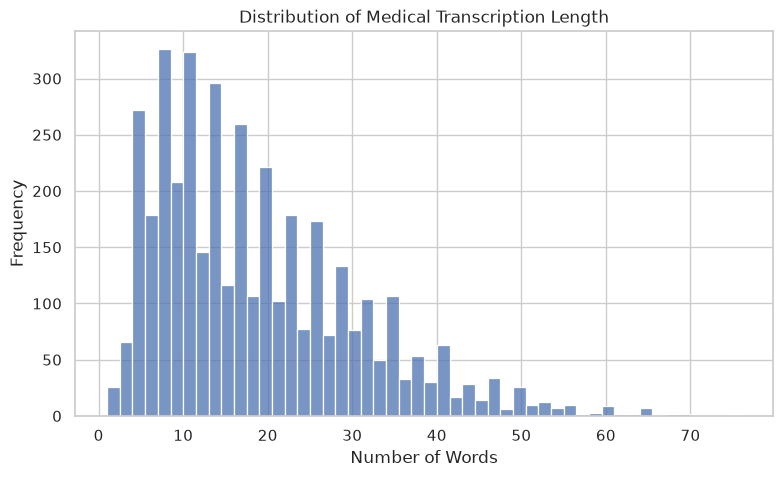

In [20]:
text_df["character_count"] = text_df["clean_text"].str.len()

text_df["word_count"] = (
    text_df["clean_text"]
    .str.split()
    .str.len()
)

display(
    text_df[
        ["character_count", "word_count"]
    ].describe()
)

plt.figure(figsize=(9, 5))

sns.histplot(
    text_df["word_count"],
    bins=50
)

plt.title("Distribution of Medical Transcription Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# Image Dataset

In [25]:
train_dataset = BreastMNIST(
    split="train",
    download=True
)

val_dataset = BreastMNIST(
    split="val",
    download=True
)

test_dataset = BreastMNIST(
    split="test",
    download=True
)

In [29]:
info = INFO["breastmnist"]

print("Dataset metadata:\n")

for key, value in info.items():
    print(f"{key}: {value}")

print("Class labels:")
print(info["label"])

Dataset metadata:

python_class: BreastMNIST
description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
url: https://zenodo.org/records/10519652/files/breastmnist.npz?download=1
MD5: 750601b1f35ba3300ea97c75c52ff8f6
url_64: https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1
MD5_64: 742edef2a1fd1524b2efff4bd7ba9364
url_128: https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1
MD5_128: 363e4b3f8d712e9b5de15470a2aaadf1
url_224: https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1
MD5_224: b56378a6eefa9fed602bb16d192d4c8b
ta

In [30]:
print("Training images shape:")
print(train_dataset.imgs.shape)

print("\nTraining labels shape:")
print(train_dataset.labels.shape)

print("\nImage data type:")
print(train_dataset.imgs.dtype)

print("\nPixel range:")
print(
    train_dataset.imgs.min(),
    "to",
    train_dataset.imgs.max()
)

Training images shape:
(546, 28, 28)

Training labels shape:
(546, 1)

Image data type:
uint8

Pixel range:
0 to 255


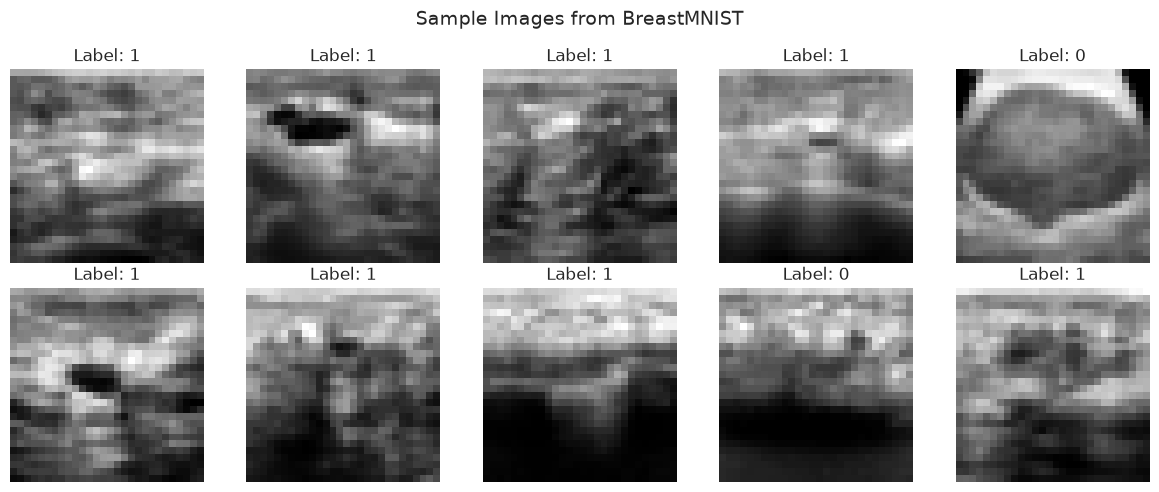

In [32]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for i, ax in enumerate(axes.flat):

    image, label = train_dataset[i]

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        f"Label: {label[0]}"
    )

    ax.axis("off")

plt.suptitle(
    "Sample Images from BreastMNIST",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [33]:
y_train = train_dataset.labels.flatten()
y_val = val_dataset.labels.flatten()
y_test = test_dataset.labels.flatten()

print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Training labels: (546,)
Validation labels: (78,)
Test labels: (156,)


In [34]:
class_counts = pd.Series(
    y_train
).value_counts().sort_index()

class_percentages = (
    class_counts / class_counts.sum()
) * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

display(class_summary)

,Count,Percentage
0,147,26.923077
1,399,73.076923


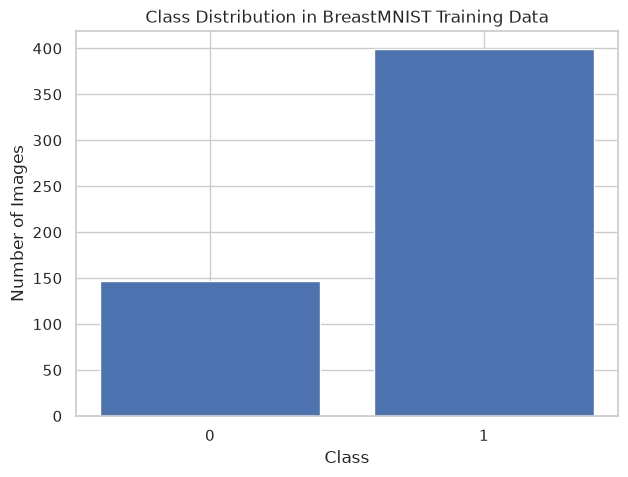

In [35]:
plt.figure(figsize=(7, 5))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title(
    "Class Distribution in BreastMNIST Training Data"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [38]:
X_train_raw = train_dataset.imgs

invalid_pixels = np.sum(
    (X_train_raw < 0)
    | (X_train_raw > 255)
)

print("Invalid pixel count:", invalid_pixels)

Invalid pixel count: 0


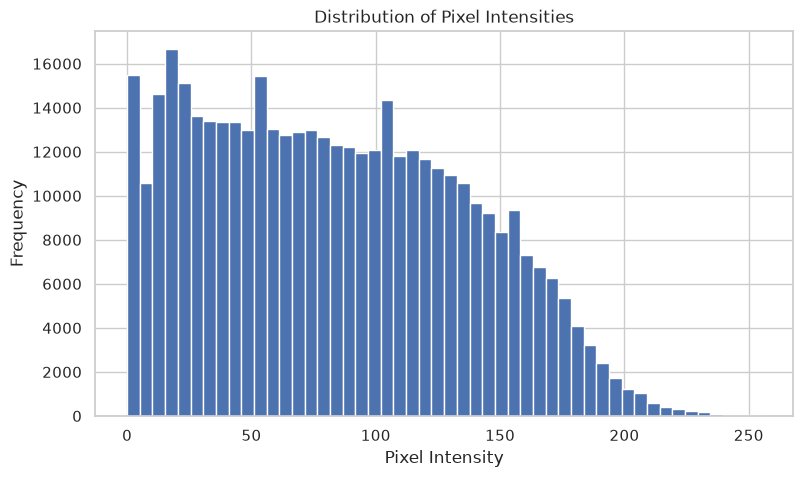

In [40]:
plt.figure(figsize=(9, 5))

plt.hist(
    X_train_raw.flatten(),
    bins=50
)

plt.title(
    "Distribution of Pixel Intensities"
)

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

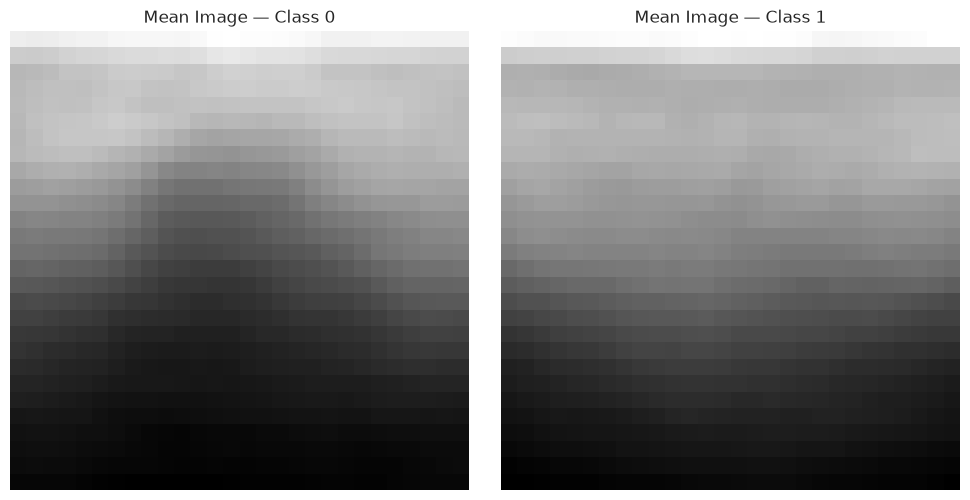

In [41]:
class_0_images = X_train_raw[
    y_train == 0
]

class_1_images = X_train_raw[
    y_train == 1
]

mean_class_0 = np.mean(
    class_0_images,
    axis=0
)

mean_class_1 = np.mean(
    class_1_images,
    axis=0
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

axes[0].imshow(
    mean_class_0.squeeze(),
    cmap="gray"
)

axes[0].set_title(
    "Mean Image — Class 0"
)

axes[0].axis("off")


axes[1].imshow(
    mean_class_1.squeeze(),
    cmap="gray"
)

axes[1].set_title(
    "Mean Image — Class 1"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()

In [42]:
X_train = train_dataset.imgs.astype(np.float32)
X_val = val_dataset.imgs.astype(np.float32)
X_test = test_dataset.imgs.astype(np.float32)

X_train /= 255.0
X_val /= 255.0
X_test /= 255.0

print("Training pixel range:")
print(
    X_train.min(),
    "to",
    X_train.max()
)

Training pixel range:
0.0 to 1.0


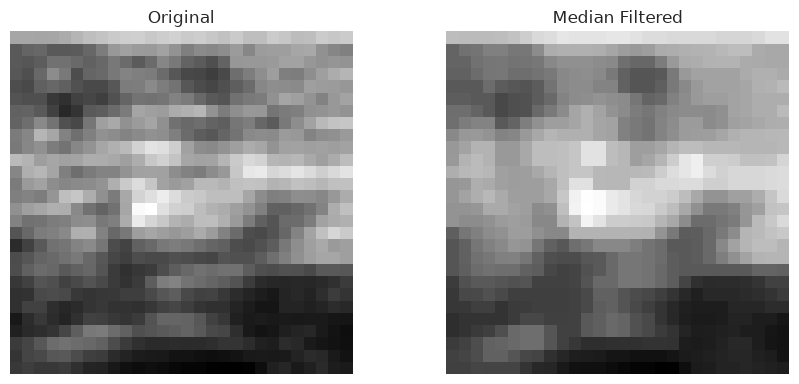

In [46]:
sample_image = X_train[0].squeeze()

median_denoised = median_filter(
    sample_image,
    size=3
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4)
)

axes[0].imshow(
    sample_image,
    cmap="gray"
)

axes[0].set_title("Original")
axes[0].axis("off")


axes[1].imshow(
    median_denoised,
    cmap="gray"
)

axes[1].set_title("Median Filtered")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [47]:
def extract_image_features(image):
    
    image = image.squeeze()
    
    # Calculate horizontal and vertical edges
    edge_x = sobel(
        image,
        axis=0
    )
    
    edge_y = sobel(
        image,
        axis=1
    )
    
    edge_magnitude = np.sqrt(
        edge_x**2
        +
        edge_y**2
    )
    
    return {
        "mean_intensity": np.mean(image),
        "std_intensity": np.std(image),
        "min_intensity": np.min(image),
        "max_intensity": np.max(image),
        "median_intensity": np.median(image),
        "q25_intensity": np.percentile(image, 25),
        "q75_intensity": np.percentile(image, 75),
        "contrast": np.max(image) - np.min(image),
        "energy": np.sum(image**2),
        "mean_edge_strength": np.mean(edge_magnitude),
        "max_edge_strength": np.max(edge_magnitude)
    }

In [49]:
train_features = pd.DataFrame([
    extract_image_features(image)
    for image in X_train
])

display(train_features.head())

display(
    train_features.describe().T
)

,mean_intensity,std_intensity,min_intensity,max_intensity,median_intensity,q25_intensity,q75_intensity,contrast,energy,mean_edge_strength,max_edge_strength
0,0.398204,0.152389,0.082353,0.792157,0.400000,0.278431,0.521569,0.709804,142.522659,0.455046,1.431346
1,0.233368,0.119642,0.007843,0.623529,0.229412,0.141176,0.301961,0.615686,53.919586,0.395428,2.086407
2,0.372854,0.123865,0.125490,0.811765,0.360784,0.274510,0.458824,0.686275,121.020432,0.384229,1.608981
3,0.425920,0.182939,0.082353,0.874510,0.474510,0.266667,0.557843,0.792157,168.461792,0.395050,2.094837
4,0.383523,0.165781,0.003922,0.823529,0.364706,0.266667,0.470588,0.819608,136.865707,0.510351,2.929010


,count,mean,std,min,25%,50%,75%,max
mean_intensity,546.0,0.327581,0.084759,0.118157,0.265160,0.323382,0.389760,0.665966
std_intensity,546.0,0.182824,0.041622,0.085227,0.152864,0.186288,0.212189,0.288046
min_intensity,546.0,0.038691,0.040752,0.000000,0.003922,0.025490,0.058824,0.301961
max_intensity,546.0,0.763348,0.108103,0.466667,0.694118,0.772549,0.838235,1.000000
median_intensity,546.0,0.315528,0.111376,0.054902,0.235294,0.305882,0.398039,0.678431
q25_intensity,546.0,0.165767,0.094596,0.003922,0.094118,0.152941,0.227451,0.592157
q75_intensity,546.0,0.472176,0.105630,0.184314,0.392402,0.482353,0.545098,0.757843
contrast,546.0,0.724657,0.105476,0.431373,0.650980,0.729412,0.796078,0.996078
energy,546.0,117.312973,48.505951,21.448368,79.783745,112.900681,151.606674,359.839233
mean_edge_strength,546.0,0.399996,0.073235,0.239485,0.352358,0.394311,0.446844,0.712052


In [50]:
train_features["intensity_range"] = (
    train_features["max_intensity"]
    -
    train_features["min_intensity"]
)

train_features["interquartile_range"] = (
    train_features["q75_intensity"]
    -
    train_features["q25_intensity"]
)

train_features["edge_to_intensity_ratio"] = (
    train_features["mean_edge_strength"]
    /
    (train_features["mean_intensity"] + 1e-8)
)

display(train_features.head())

,mean_intensity,std_intensity,min_intensity,max_intensity,median_intensity,q25_intensity,q75_intensity,contrast,energy,mean_edge_strength,max_edge_strength,intensity_range,interquartile_range,edge_to_intensity_ratio
0,0.398204,0.152389,0.082353,0.792157,0.400000,0.278431,0.521569,0.709804,142.522659,0.455046,1.431346,0.709804,0.243137,1.142745
1,0.233368,0.119642,0.007843,0.623529,0.229412,0.141176,0.301961,0.615686,53.919586,0.395428,2.086407,0.615686,0.160784,1.694436
2,0.372854,0.123865,0.125490,0.811765,0.360784,0.274510,0.458824,0.686275,121.020432,0.384229,1.608981,0.686275,0.184314,1.030509
3,0.425920,0.182939,0.082353,0.874510,0.474510,0.266667,0.557843,0.792157,168.461792,0.395050,2.094837,0.792157,0.291176,0.927520
4,0.383523,0.165781,0.003922,0.823529,0.364706,0.266667,0.470588,0.819608,136.865707,0.510351,2.929010,0.819608,0.203922,1.330689


In [51]:
def augment_image(image):
    
    # Remove channel dimension temporarily
    image = image.squeeze()
    
    # Small random rotation
    angle = np.random.uniform(-5, 5)
    
    augmented = rotate(
        image,
        angle=angle,
        reshape=False,
        mode="nearest"
    )
    
    # Small random horizontal/vertical shift
    shift_amount = np.random.uniform(-1, 1, size=2)
    
    augmented = shift(
        augmented,
        shift=shift_amount,
        mode="nearest"
    )
    
    # Ensure valid normalized range
    augmented = np.clip(
        augmented,
        0,
        1
    )
    
    return augmented.astype(np.float32)

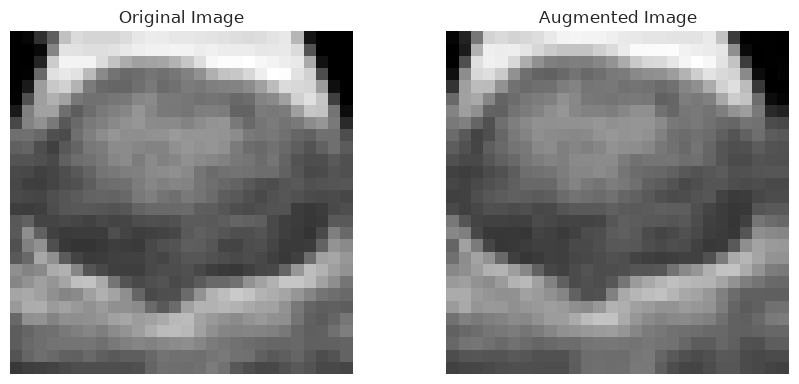

In [62]:
original = X_train[4].squeeze()

augmented = augment_image(
    X_train[4]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4)
)

axes[0].imshow(
    original,
    cmap="gray"
)

axes[0].set_title("Original Image")
axes[0].axis("off")


axes[1].imshow(
    augmented,
    cmap="gray"
)

axes[1].set_title("Augmented Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Signal Data

In [4]:
ecg = electrocardiogram()

sampling_rate = 360

print("ECG shape:", ecg.shape)
print("Number of samples:", len(ecg))
print("Duration in seconds:", len(ecg) / sampling_rate)

ECG shape: (108000,)
Number of samples: 108000
Duration in seconds: 300.0


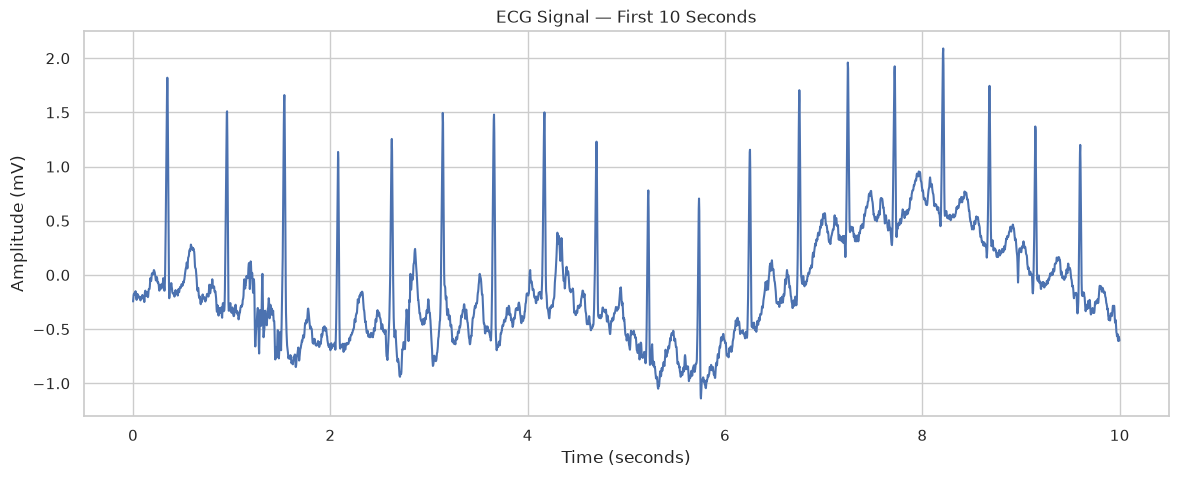

In [5]:
time = np.arange(len(ecg)) / sampling_rate

plt.figure(figsize=(14, 5))

plt.plot(
    time[:10 * sampling_rate],
    ecg[:10 * sampling_rate]
)

plt.title("ECG Signal — First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")

plt.show()

In [7]:
def bandpass_filter(
    signal,
    lowcut,
    highcut,
    fs,
    order=4
):
    
    nyquist = 0.5 * fs
    
    low = lowcut / nyquist
    high = highcut / nyquist
    
    b, a = butter(
        order,
        [low, high],
        btype="band"
    )
    
    filtered_signal = filtfilt(
        b,
        a,
        signal
    )
    
    return filtered_signal

ecg_filtered = bandpass_filter(
    ecg,
    lowcut=0.5,
    highcut=40,
    fs=sampling_rate
)

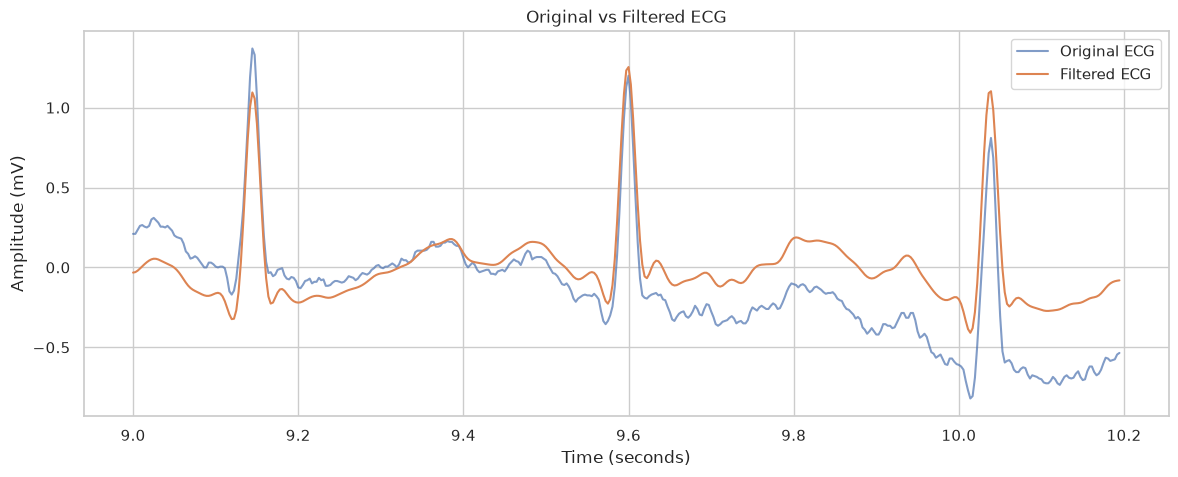

In [8]:
start = 9 * sampling_rate
end = int(10.2 * sampling_rate)

plt.figure(figsize=(14, 5))

plt.plot(
    time[start:end],
    ecg[start:end],
    label="Original ECG",
    alpha=0.7
)

plt.plot(
    time[start:end],
    ecg_filtered[start:end],
    label="Filtered ECG"
)

plt.title("Original vs Filtered ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")

plt.legend()
plt.show()

In [9]:
ecg_mean = ecg_filtered.mean()
ecg_std = ecg_filtered.std()

ecg_normalized = (
    ecg_filtered - ecg_mean
) / ecg_std

print("Mean after normalization:", ecg_normalized.mean())
print("Standard deviation:", ecg_normalized.std())

Mean after normalization: -1.5954316057576323e-18
Standard deviation: 1.0


In [10]:
WINDOW_SECONDS = 5

WINDOW_SIZE = (
    WINDOW_SECONDS * sampling_rate
)

NUM_WINDOWS = len(ecg_normalized) // WINDOW_SIZE

signal_windows = ecg_normalized[
    :NUM_WINDOWS * WINDOW_SIZE
].reshape(
    NUM_WINDOWS,
    WINDOW_SIZE
)

signal_windows = signal_windows.astype(np.float32)

print("Signal window tensor shape:")
print(signal_windows.shape)

Signal window tensor shape:
(60, 1800)


In [11]:
def extract_signal_features(window):
    
    return {
        "mean": np.mean(window),
        "std": np.std(window),
        "min": np.min(window),
        "max": np.max(window),
        "range": np.ptp(window),
        "energy": np.sum(window ** 2),
        "mean_absolute_value": np.mean(np.abs(window))
    }

signal_features = pd.DataFrame(
    [
        extract_signal_features(window)
        for window in signal_windows
    ]
)

display(signal_features.head())

display(signal_features.describe())

,mean,std,min,max,range,energy,mean_absolute_value
0,0.023410,0.864440,-1.323456,5.092521,6.415977,1346.046997,0.519758
1,-0.006466,0.673005,-1.056962,3.908225,4.965186,815.358948,0.412980
2,-0.003934,0.652378,-1.048052,3.587795,4.635848,766.102966,0.372546
3,0.008633,1.126776,-1.907000,5.532056,7.439055,2285.458252,0.682996
4,0.010813,0.980489,-2.013973,5.128770,7.142743,1730.656372,0.616996


,mean,std,min,max,range,energy,mean_absolute_value
count,6.000000e+01,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,4.501392e-10,0.987238,-1.974595,5.097237,7.071832,1799.999878,0.606415
std,2.538208e-02,0.158577,0.598912,0.790185,1.014425,549.218689,0.119245
min,-7.090084e-02,0.469738,-4.365462,2.557551,4.231677,401.050781,0.274387
25%,-1.347381e-02,0.922772,-2.204772,4.475148,6.411532,1537.036621,0.550354
50%,-1.110820e-04,0.993267,-2.015231,5.154497,7.189032,1777.013916,0.596661
75%,1.081733e-02,1.079110,-1.703412,5.726050,7.811046,2096.536865,0.676580
max,6.749131e-02,1.396435,-0.726895,6.526565,9.017020,3510.268799,0.965590
